# ✈ Airline Operational Risk EDA

## Problem Statement

Airlines operate in a cost-sensitive environment where even minor schedule disruptions can cascade into large financial and reputational impacts. The goal is to minimize operational uncertainty by leveraging data analytics to detect patterns of instability and
reduce disruption-related losses

## Data Definition

- **YEAR**  
  Year of the flight operation.

- **QUARTER**  
  Quarter of the year (1–4).

- **MONTH**  
  Month of operation (1–12).

- **DAY_OF_WEEK**  
  Day of the week (1 = Monday, 7 = Sunday).


- **MKT_UNIQUE_CARRIER**  
  Unique airline carrier code (e.g., AA, DL, UA).

- **ORIGIN_AIRPORT_ID**  
  Unique numeric identifier of departure airport.

- **ORIGIN**  
  Departure airport code (e.g., JFK, LAX).

- **DEST_AIRPORT_ID**  
  Unique numeric identifier of destination airport.

- **DEST**  
  Destination airport code.


- **CRS_DEP_TIME**  
  Scheduled departure time (in HHMM format).

- **DEP_TIME_BLK**  
  Scheduled departure time block (e.g., 0800–0859).

- **TAXI_OUT**  
  Time (in minutes) aircraft spent taxiing before takeoff.

- **TAXI_IN**  
  Time (in minutes) aircraft spent taxiing after landing.


- **CANCELLED**  
  Binary indicator (1 = Flight cancelled, 0 = Not cancelled).

- **DIVERTED**  
  Binary indicator (1 = Flight diverted, 0 = Not diverted).


- **ACTUAL_ELAPSED_TIME**  
  Total actual flight duration (gate-to-gate) in minutes.

- **AIR_TIME**  
  Actual time spent in air (in minutes).

- **DISTANCE**  
  Distance between origin and destination airports (in miles).

- **DISTANCE_GROUP**  
  Categorized distance interval group.


- **CARRIER_DELAY**  
  Delay caused by airline operations.

- **WEATHER_DELAY**  
  Delay due to weather conditions.

- **NAS_DELAY**  
  Delay due to National Airspace System (traffic congestion).

- **SECURITY_DELAY**  
  Delay due to security-related issues.

- **LATE_AIRCRAFT_DELAY**  
  Delay caused by late arrival of the same aircraft.


- **OPERATIONAL_RISK**  
  Risk classification label indicating operational risk level of the flight.

## Table of Contents


1. **[Import Libraries](#import_lib)** 
2. **[Set Options](#set_options)** 
3. **[Read Data](#Read_Data)** 
4. **[Understand  and Prepare the Data](#Understand_Data)**
5. **[Understand the variables](#Understanding_variables)**
6. **[Check for Missing Values](#missing)**
7. **[Study Correlation](#correlation)**
8. **[Detect Outliers](#outliers)**
9. **[Create a new variable 'region'](#region)**
10. **[Some more analysis](#more)** 


# Importing Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,accuracy_score,recall_score,r2_score,precision_score,roc_auc_score,confusion_matrix

import warnings 
warnings.filterwarnings("ignore")

In [2]:
PROJECT_ROOT = Path.cwd().parent
data_path = PROJECT_ROOT / "data" / "train_sample_2024.csv"
data=pd.read_csv(data_path)
df=data.copy()

# Data Understanding

In [3]:
# Checking the number of rows and columns
df.shape

(200001, 25)

In [4]:
# Checking out the basic info of the data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200001 entries, 0 to 200000
Data columns (total 25 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   YEAR                 200001 non-null  int64  
 1   QUARTER              200001 non-null  int64  
 2   MONTH                200001 non-null  int64  
 3   DAY_OF_WEEK          200001 non-null  int64  
 4   MKT_UNIQUE_CARRIER   200001 non-null  str    
 5   ORIGIN_AIRPORT_ID    200001 non-null  int64  
 6   ORIGIN               200001 non-null  str    
 7   DEST_AIRPORT_ID      200001 non-null  int64  
 8   DEST                 200001 non-null  str    
 9   CRS_DEP_TIME         200001 non-null  int64  
 10  DEP_TIME_BLK         200001 non-null  str    
 11  TAXI_OUT             200001 non-null  float64
 12  TAXI_IN              200001 non-null  float64
 13  CANCELLED            200001 non-null  float64
 14  DIVERTED             200001 non-null  float64
 15  ACTUAL_ELAPSED_TIME  200001 

In [5]:
# Checking duplicates
df.duplicated().sum()

np.int64(0)

In [6]:
# displaying top 5 data
df.head()

,YEAR,QUARTER,MONTH,DAY_OF_WEEK,MKT_UNIQUE_CARRIER,ORIGIN_AIRPORT_ID,ORIGIN,DEST_AIRPORT_ID,DEST,CRS_DEP_TIME,...,ACTUAL_ELAPSED_TIME,AIR_TIME,DISTANCE,DISTANCE_GROUP,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,OPERATIONAL_RISK
0,2024,2,6,3,AA,11057,CLT,13360,MLB,2131,...,120.0,69.0,490.0,2,0.0,0.0,0.0,0.0,0.0,0
1,2024,2,4,3,WN,13851,OKC,15016,STL,620,...,74.0,63.0,462.0,2,0.0,0.0,0.0,0.0,0.0,0
2,2024,3,8,2,UA,14794,SGU,11292,DEN,1030,...,122.0,77.0,517.0,3,0.0,0.0,0.0,0.0,0.0,0
3,2024,3,8,6,B6,10721,BOS,10693,BNA,1353,...,170.0,143.0,942.0,4,0.0,0.0,0.0,0.0,0.0,0
4,2024,3,8,7,WN,14057,PDX,13232,MDW,1335,...,214.0,201.0,1751.0,8,0.0,0.0,0.0,0.0,0.0,0


### INFERENCE
**1) The dataset has 2 Lakh rows and 25 columns.**

**2) There 16 numerical columns and 9 categorical columns.**

**3) There are no duplicate rows present in the dataset.**


## Understanding the variables

In [7]:
for i in df.columns:
    print(i)
    print(df[i].unique())
    print()

YEAR
[2024]

QUARTER
[2 3 4 1]

MONTH
[ 6  4  8 10  5  9  7  1 12  2  3 11]

DAY_OF_WEEK
[3 2 6 7 4 1 5]

MKT_UNIQUE_CARRIER
<StringArray>
['AA', 'WN', 'UA', 'B6', 'AS', 'DL', 'HA', 'G4', 'NK', 'F9']
Length: 10, dtype: str

ORIGIN_AIRPORT_ID
[11057 13851 14794 10721 14057 14685 14107 14252 13244 15919 10994 10372
 14843 13377 13930 11298 10397 13342 10693 11066 12982 12889 11292 13204
 14679 12478 13495 14747 11433 13487 12266 14698 15323 12758 13830 14771
 11648 11109 12953 14709 11618 14122 14831 15376 14027 12173 12892 14893
 11278 10800 13871 11193 11259 14783 12945 11624 12954 10713 13303 14262
 14193 10299 11697 13433 10785 11995 10170 10747 14869 13485 14100 13232
 10792 11503 12191 10821 14307 14683 15304 14492 12278 12343 14952 11986
 11996 11637 11140 13577 10466 11423 12339 10868 15016 10620 14321 11233
 10849 11638 14108 14908 15370 11267 10279 11003 10529 11884 10423 11042
 15624 14576 12264 10140 14524 11612 15096 10245 13158 11122 12896 13931
 13296 10980 13795 12402 102

In [8]:
# Separating numerical and categorical columns
num=df.select_dtypes(include=np.number).columns.to_list()
cat=df.select_dtypes(include=object).columns.to_list()

In [9]:
# Summary statistic of numerical variables
df[num].describe().T

,count,mean,std,min,25%,50%,75%,max
YEAR,200001.0,2024.000000,0.000000,2024.0,2024.0,2024.0,2024.0,2024.0
QUARTER,200001.0,2.553527,1.118770,1.0,2.0,3.0,4.0,4.0
MONTH,200001.0,6.697312,3.418577,1.0,4.0,7.0,10.0,12.0
DAY_OF_WEEK,200001.0,3.916985,2.005306,1.0,2.0,4.0,6.0,7.0
ORIGIN_AIRPORT_ID,200001.0,12657.722221,1530.495468,10135.0,11292.0,12889.0,14057.0,16869.0
DEST_AIRPORT_ID,200001.0,12655.014725,1526.493971,10135.0,11292.0,12889.0,14057.0,16869.0
CRS_DEP_TIME,200001.0,1326.170854,490.454934,1.0,910.0,1320.0,1734.0,2359.0
TAXI_OUT,200001.0,18.064275,9.802991,1.0,12.0,16.0,21.0,181.0
TAXI_IN,200001.0,8.357388,6.921101,1.0,5.0,6.0,10.0,444.0
CANCELLED,200001.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


### INFERENCE
**1) OPERATIONAL_RISK**: About 20.6% of flights are risky, so the data is imbalanced with most flights being normal.

**2) ACTUAL_ELAPSED_TIME**: Average flight time is 138 minutes with high variation, suggesting longer flights may have higher operational complexity.

**3) CARRIER_DELAY**: Most flights have no delay, but a few have very large delays, indicating rare but high-impact events.


In [10]:
# Summary statistic of categorical variables
df[cat].describe().T


,count,unique,top,freq
MKT_UNIQUE_CARRIER,200001,10,AA,50586
ORIGIN,200001,358,ATL,9210
DEST,200001,359,ATL,9147
DEP_TIME_BLK,200001,19,0700-0759,13864


### INFERENCE

**1) MKT_UNIQUE_CARRIER:** There are 10 carriers, with AA being the most frequent (~50k flights), indicating one airline dominates the dataset.

**2) ORIGIN & DEST:** Around 358–359 airports are present, showing good geographic diversity; ATL is the most common hub for both origin and destination.

**3)DEP_TIME_BLK:** There are 19 time blocks, with 0700–0759 being the busiest departure window, suggesting peak morning traffic.


## Checking for missing values

In [11]:
df.isna().sum()

YEAR                   0
QUARTER                0
MONTH                  0
DAY_OF_WEEK            0
MKT_UNIQUE_CARRIER     0
ORIGIN_AIRPORT_ID      0
ORIGIN                 0
DEST_AIRPORT_ID        0
DEST                   0
CRS_DEP_TIME           0
DEP_TIME_BLK           0
TAXI_OUT               0
TAXI_IN                0
CANCELLED              0
DIVERTED               0
ACTUAL_ELAPSED_TIME    0
AIR_TIME               0
DISTANCE               0
DISTANCE_GROUP         0
CARRIER_DELAY          0
WEATHER_DELAY          0
NAS_DELAY              0
SECURITY_DELAY         0
LATE_AIRCRAFT_DELAY    0
OPERATIONAL_RISK       0
dtype: int64

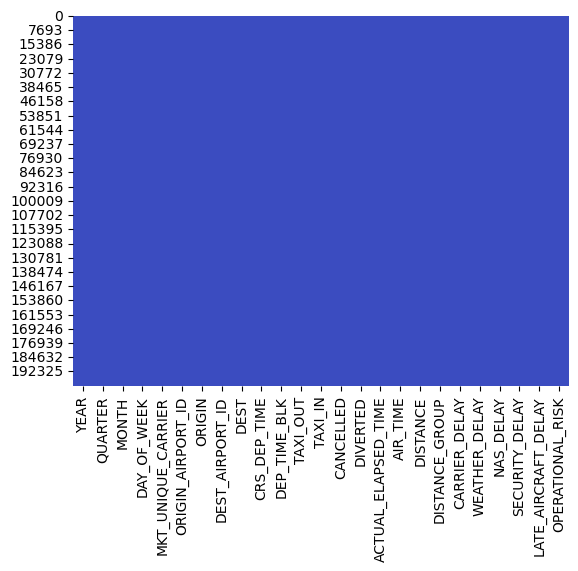

In [12]:
sns.heatmap(df.isnull(),cmap='coolwarm',cbar=False)
plt.show()

### INFERENCE

**There are no null values present in the data**


## Checking For Outliers

In [13]:
q3=df[num].quantile(0.75)
q1=df[num].quantile(0.25)
IQR =q3-q1

upper=q3 + 1.5*IQR
lower=q1 - 1.5*IQR

In [14]:
df[((df[num]>upper)|(df[num]<lower)).any(axis=1)]

,YEAR,QUARTER,MONTH,DAY_OF_WEEK,MKT_UNIQUE_CARRIER,ORIGIN_AIRPORT_ID,ORIGIN,DEST_AIRPORT_ID,DEST,CRS_DEP_TIME,...,ACTUAL_ELAPSED_TIME,AIR_TIME,DISTANCE,DISTANCE_GROUP,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,OPERATIONAL_RISK
0,2024,2,6,3,AA,11057,CLT,13360,MLB,2131,...,120.0,69.0,490.0,2,0.0,0.0,0.0,0.0,0.0,0
2,2024,3,8,2,UA,14794,SGU,11292,DEN,1030,...,122.0,77.0,517.0,3,0.0,0.0,0.0,0.0,0.0,0
17,2024,4,10,5,AA,11298,DFW,11057,CLT,1715,...,163.0,115.0,936.0,4,0.0,0.0,0.0,0.0,0.0,0
22,2024,3,8,1,DL,10721,BOS,14869,SLC,930,...,307.0,282.0,2105.0,9,0.0,0.0,0.0,0.0,0.0,0
28,2024,4,12,1,DL,13204,MCO,10397,ATL,900,...,104.0,61.0,404.0,2,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199996,2024,3,7,5,AA,11298,DFW,11433,DTW,1920,...,136.0,120.0,986.0,4,0.0,0.0,0.0,0.0,42.0,1
199997,2024,2,5,2,DL,12953,LGA,10868,CAE,1345,...,132.0,93.0,617.0,3,0.0,0.0,10.0,0.0,12.0,1
199998,2024,2,5,7,WN,12402,ITO,12173,HNL,1915,...,58.0,44.0,216.0,1,110.0,0.0,3.0,0.0,5.0,1
199999,2024,2,4,1,WN,10821,BWI,14107,PHX,2120,...,388.0,289.0,1999.0,8,24.0,0.0,83.0,0.0,0.0,1


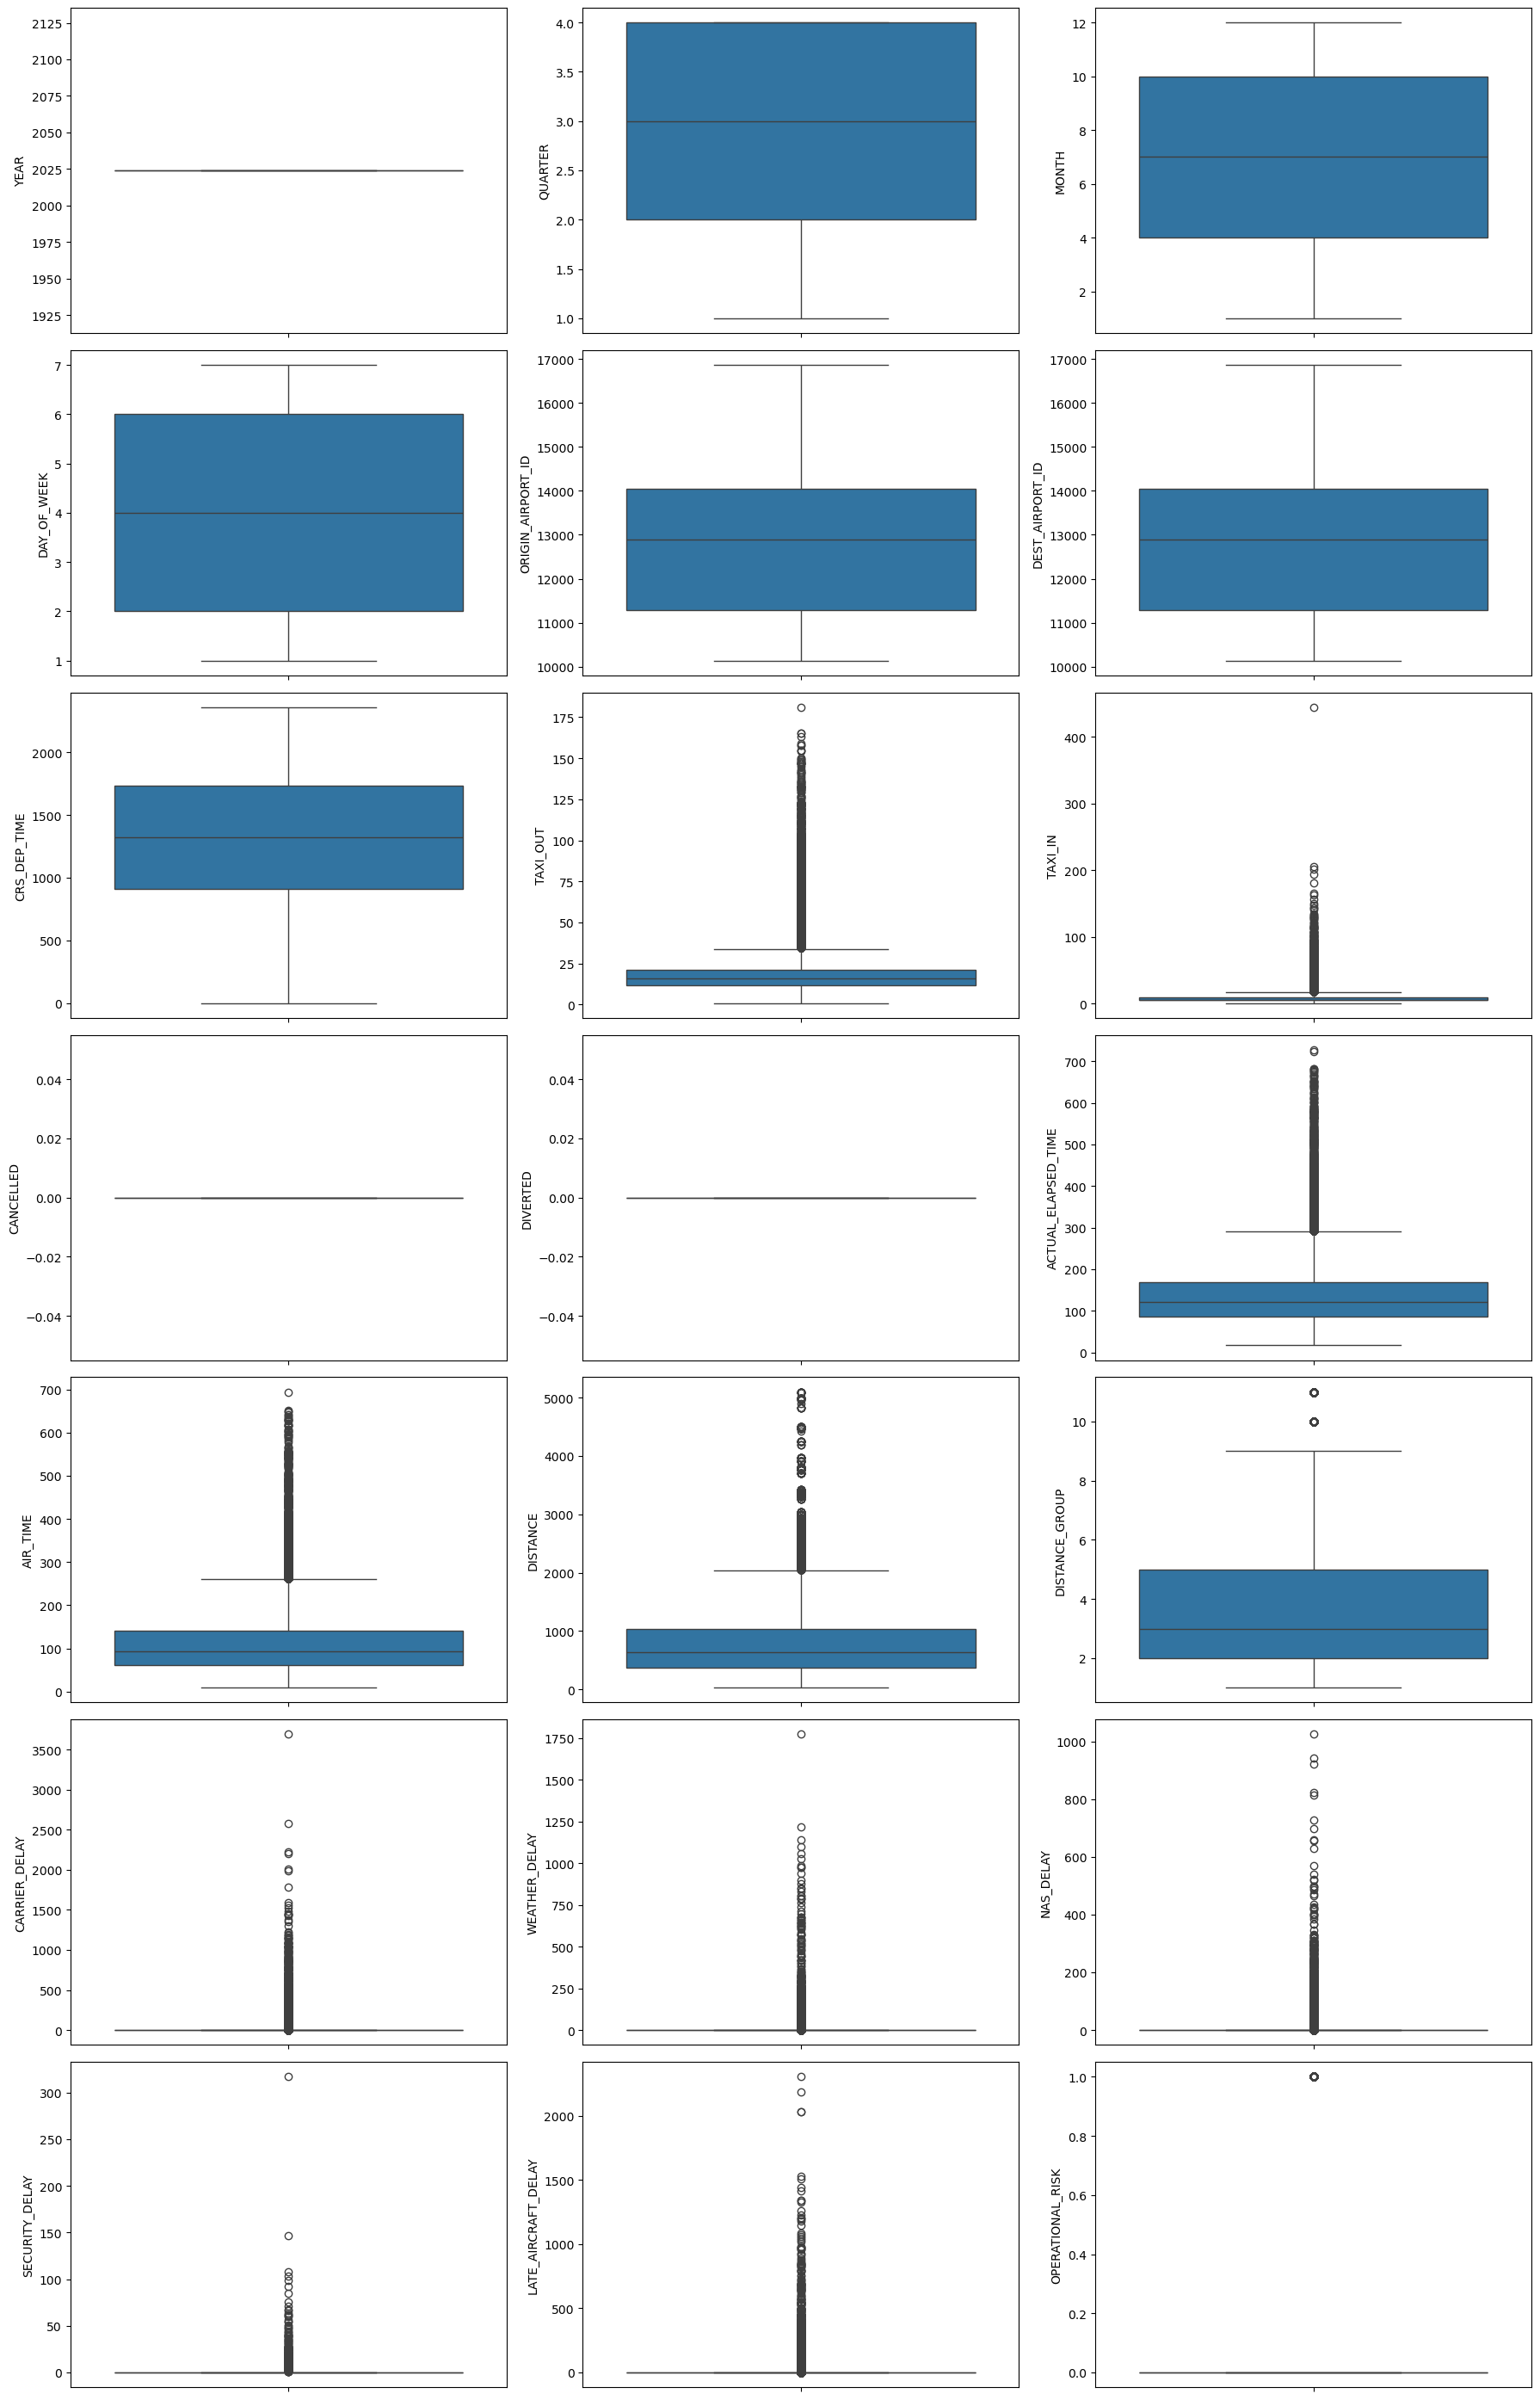

In [15]:
# Checking outliers by plotting
plt.figure(figsize=(18,28))
t=1

for i in num:
    plt.subplot(7,3,t)
    sns.boxplot(df[i])
    t+=1
plt.tight_layout()
plt.show()

### INFERENCE 
**There are 62807 records in the data which are outliers.**

## Univariate Analysis

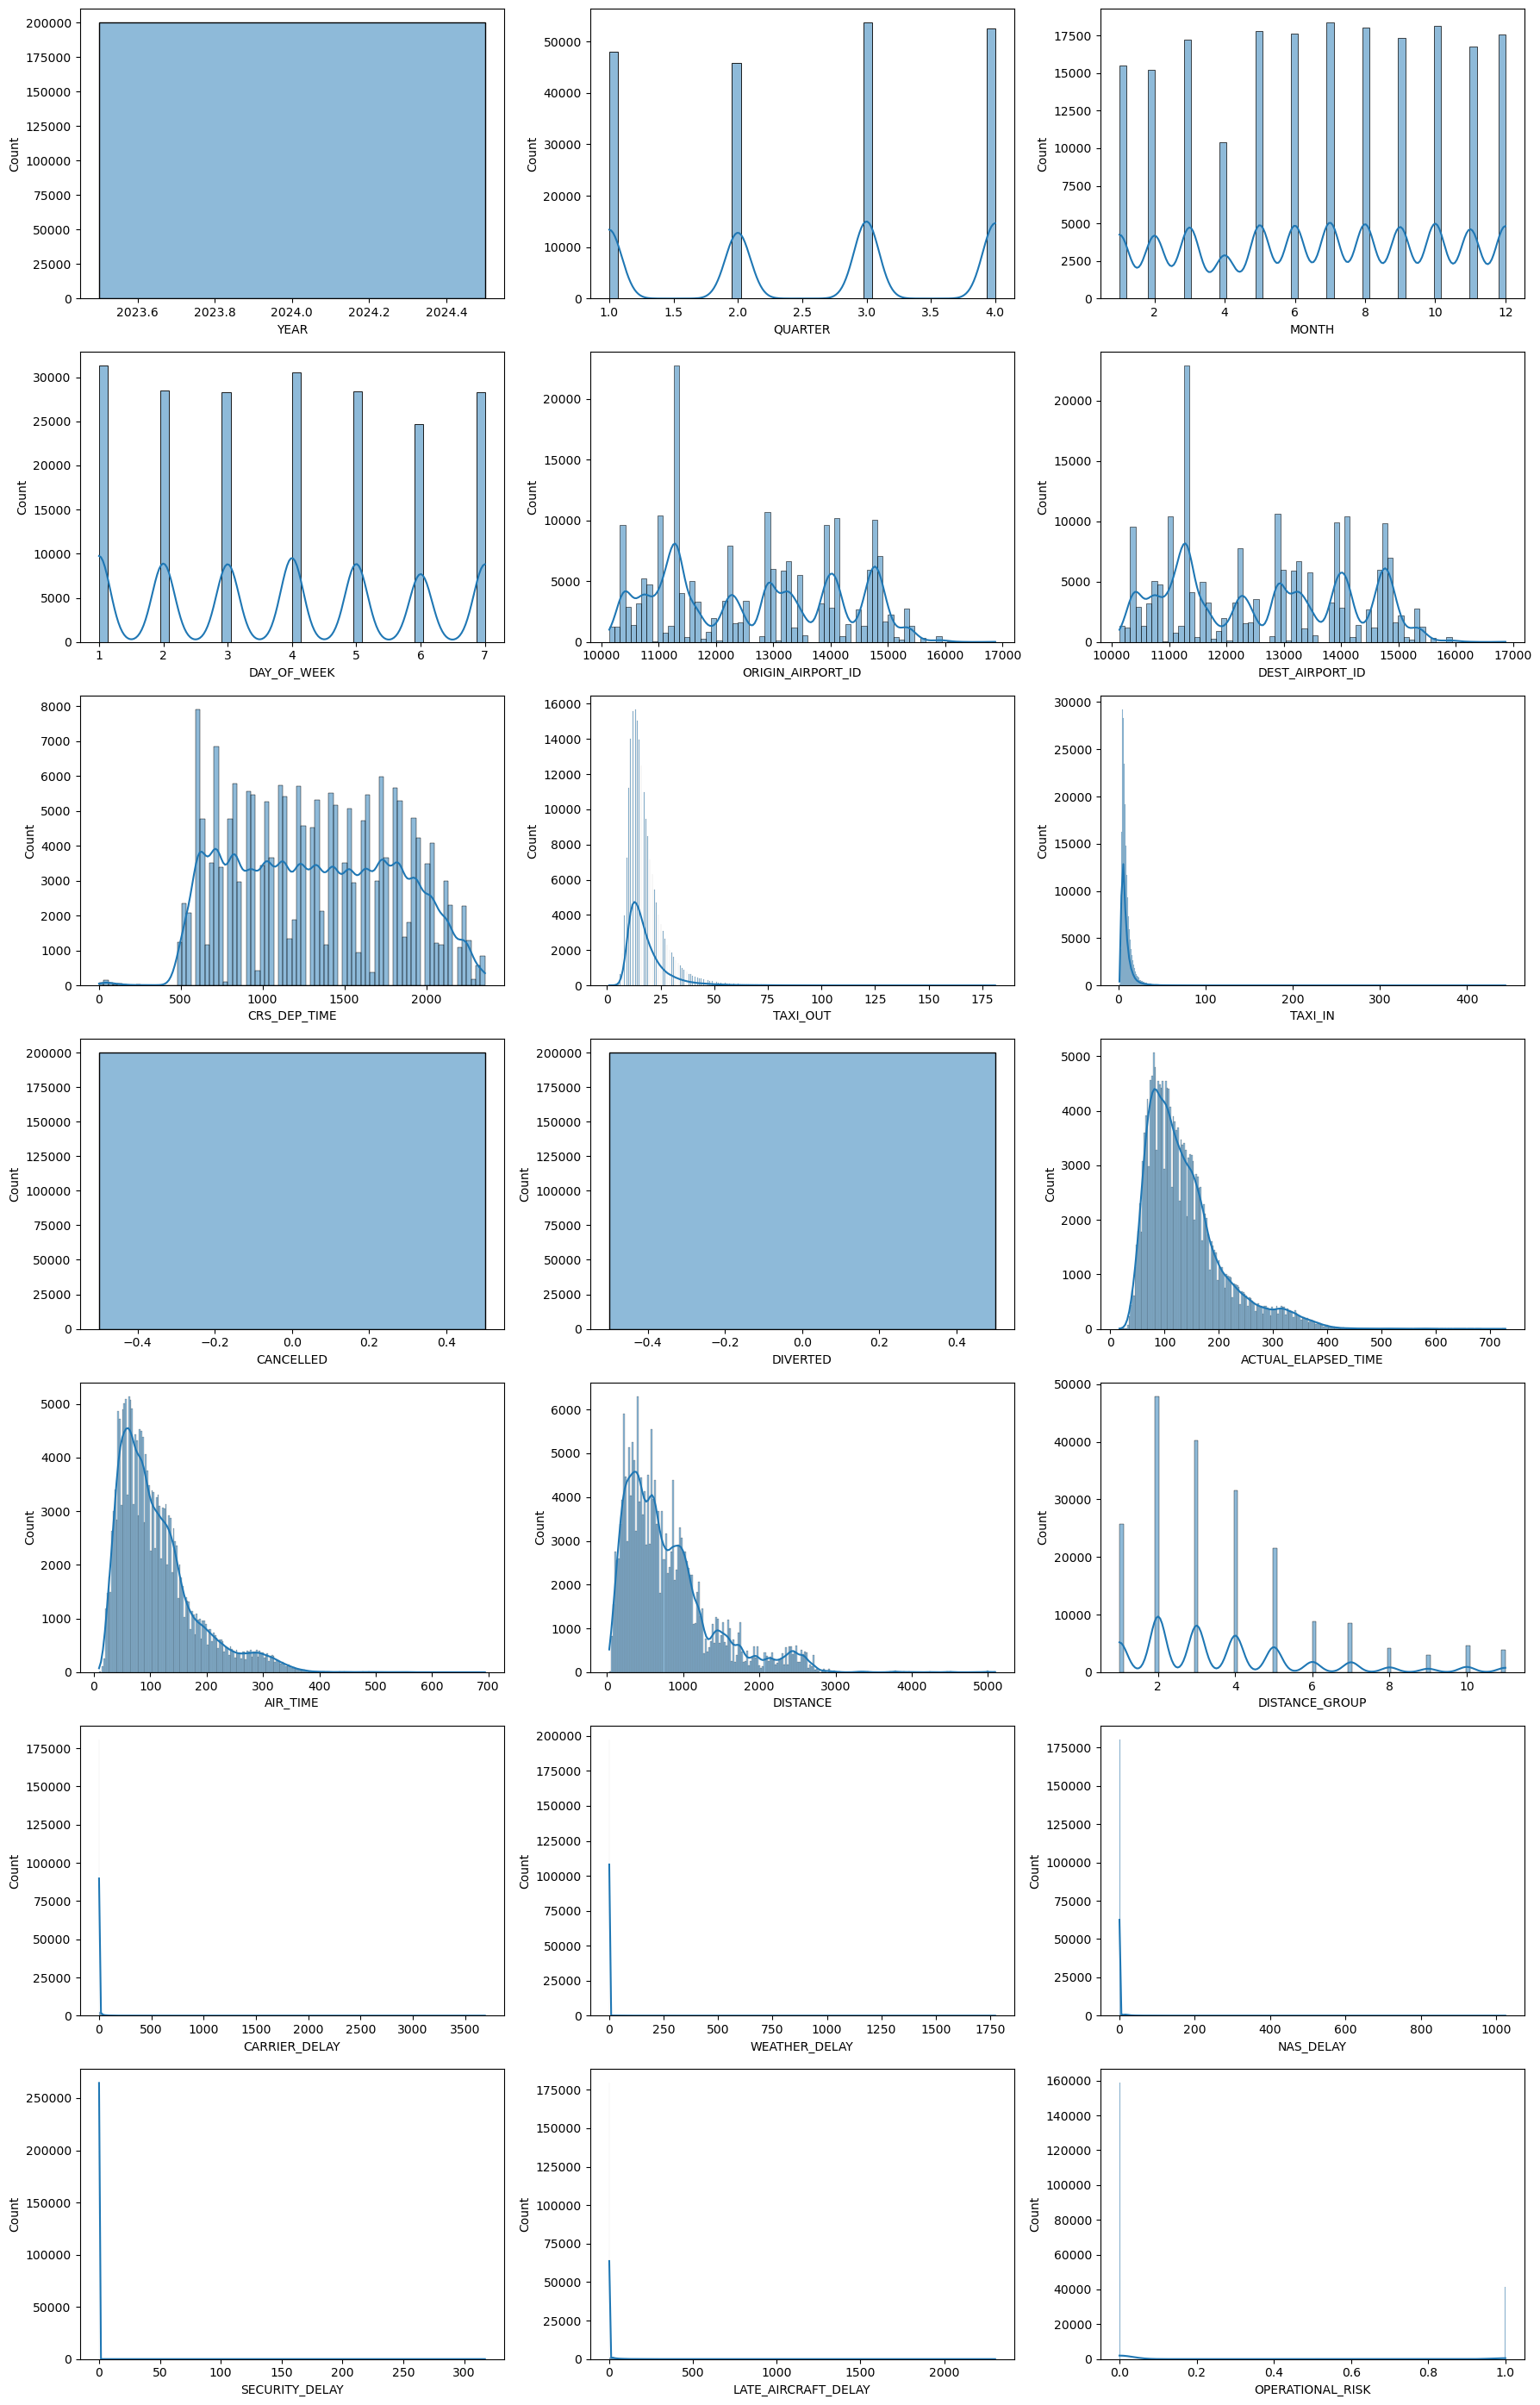

In [16]:
# Numerical column Ploting
plt.figure(figsize=(18,28))
t=1
for i in num:
    plt.subplot(7,3,t)
    sns.histplot(df[i],kde=True)
    t+=1
plt.tight_layout()
plt.show()

### INFERENCE


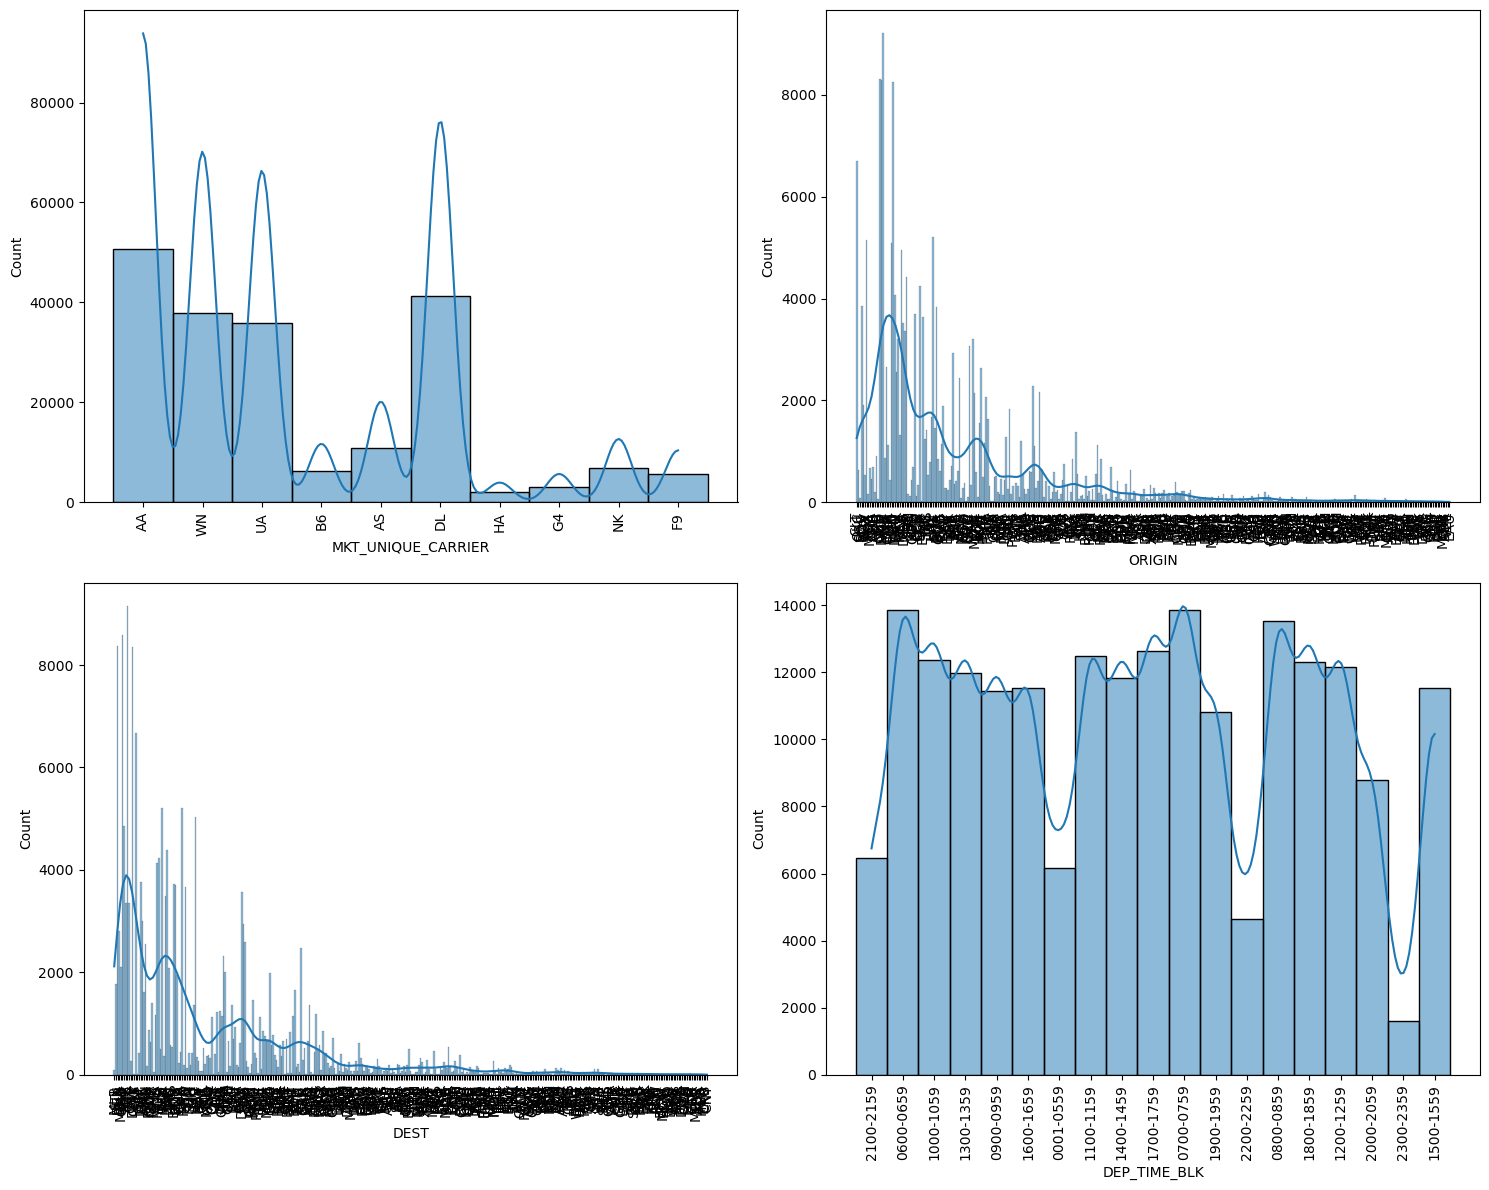

In [17]:
# Categorical column Ploting
plt.figure(figsize=(15,12))
t=1
for i in cat:
    plt.subplot(2,2,t)
    sns.histplot(df[i],kde=True)
    plt.xticks(rotation=90)
    t+=1
plt.tight_layout()
plt.show()

### INFERENCE

## Bivariate Analysis

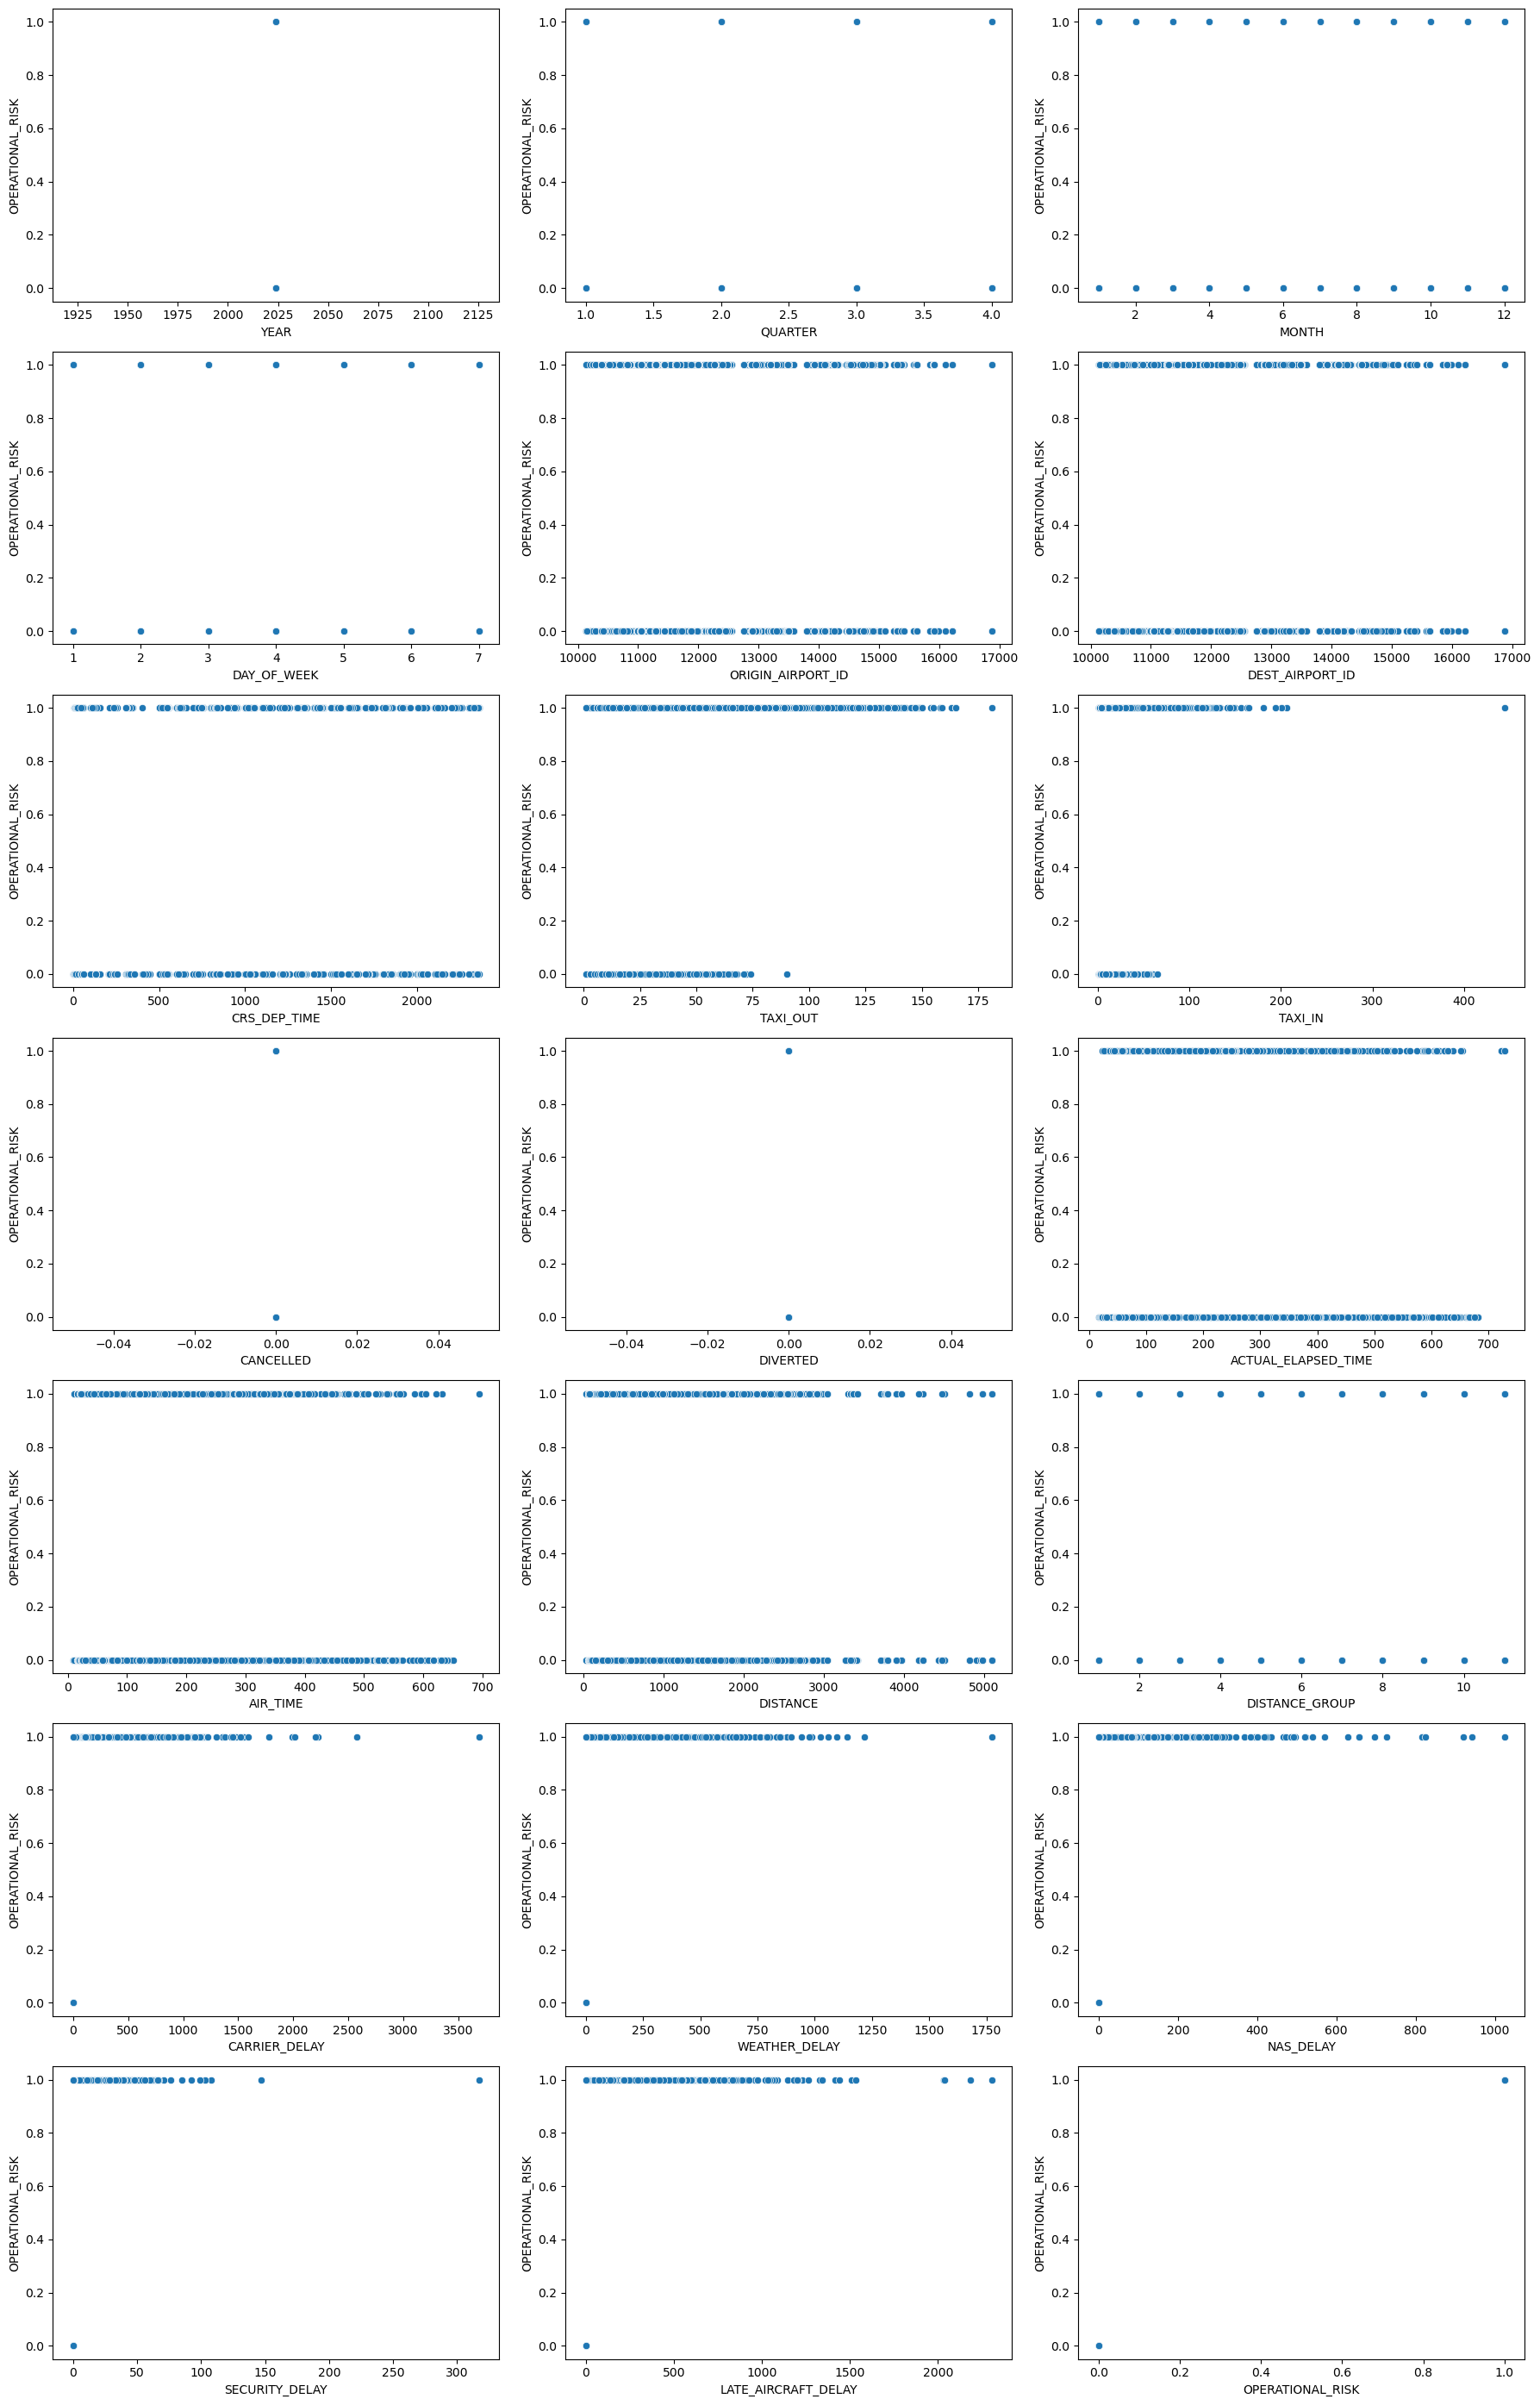

In [18]:
# Numrical vs Numerical Ploting
plt.figure(figsize=(18,28))
t=1
for i in num:
    plt.subplot(7,3,t)
    sns.scatterplot(df,x=i,y=df['OPERATIONAL_RISK'])
    t+=1
plt.tight_layout()
plt.show()

### INFERENCE

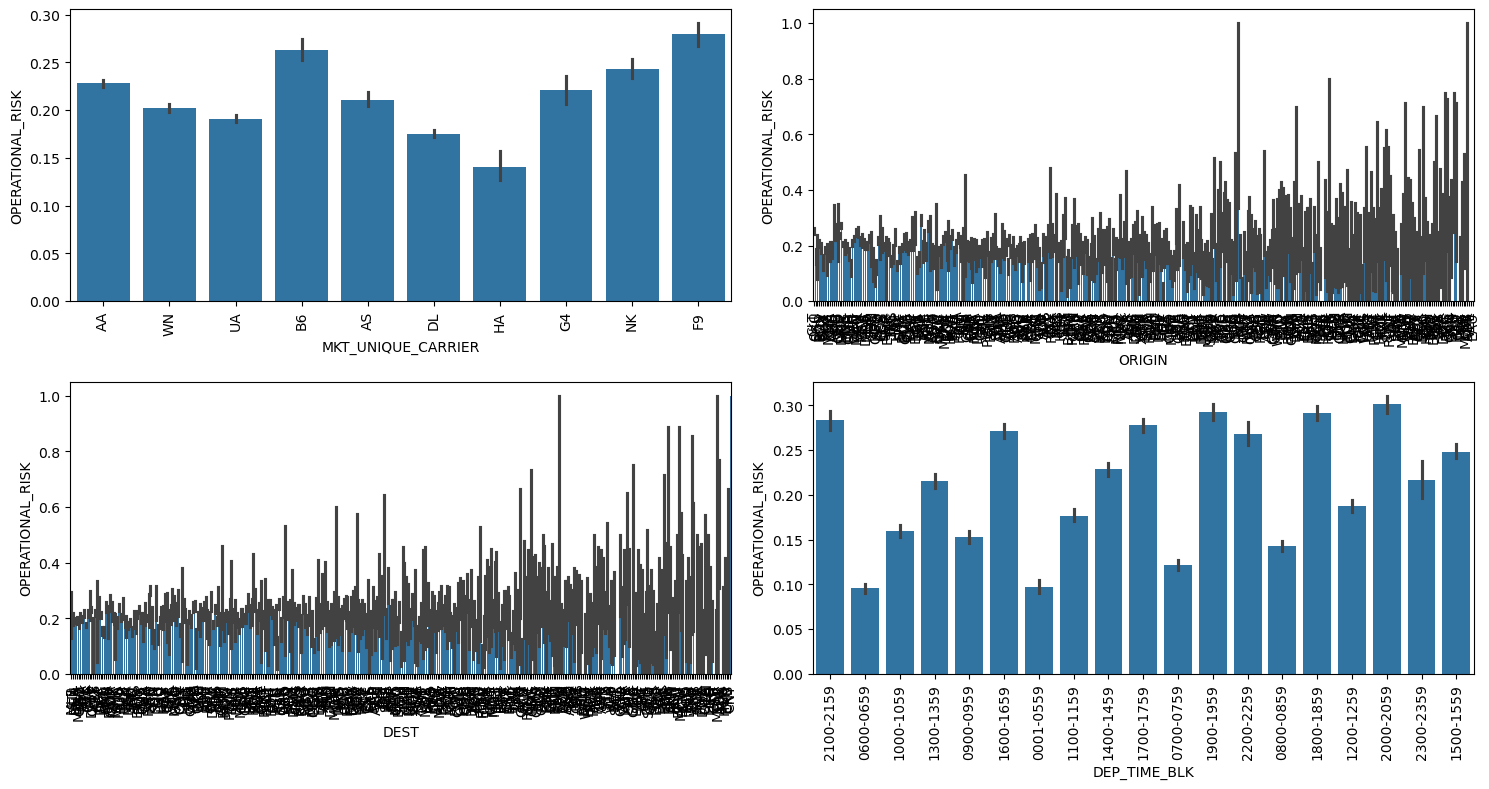

In [19]:
# Categorical vs Numerical Ploting
plt.figure(figsize=(15,8))
t=1
for i in cat:
    plt.subplot(2,2,t)
    sns.barplot(df,x=i,y=df['OPERATIONAL_RISK'])
    plt.xticks(rotation=90)
    t+=1
plt.tight_layout()
plt.show()

### INFERENCE

## Multivariate Analysis

In [20]:
# Pairplot
plt.figure(figsize=(15,8))
sns.pairplot(df[num])
plt.tight_layout()
plt.show()

<Figure size 1500x800 with 0 Axes>

KeyboardInterrupt: 

### INFERENCE

In [ ]:
# Heatmap
dropped_col=df.drop(columns=['YEAR','ORIGIN_AIRPORT_ID','DEST_AIRPORT_ID','CANCELLED','DIVERTED'])
plt.figure(figsize=(15,8))

sns.heatmap(round(dropped_col.corr(numeric_only=True),3),annot=True,cmap='viridis')
plt.show()

### INFERENCE

1) NAS_DELAY and LATE_AIRCRAFT_DELAY have the highest positive correlation (~0.36) with operational risk, indicating delays from airspace and late aircraft are major risk drivers.

2) CARRIER_DELAY (~0.27) and TAXI_OUT (~0.26) show moderate positive relationships, suggesting airline-related delays and ground congestion also increase risk.

3) QUARTER, MONTH, DAY_OF_WEEK, AIR_TIME, DISTANCE variables have very weak correlation with operational risk, indicating they contribute less to predicting risk.



## Data Preprocessing


In [ ]:
# Creating copy of df
df_model=df.copy()

In [ ]:
le=LabelEncoder()
df_model['MKT_UNIQUE_CARRIER']=le.fit_transform(df_model['MKT_UNIQUE_CARRIER'])


## Model Building

In [ ]:
### Baseline Model
features=df_model.drop(
    columns=['OPERATIONAL_RISK','YEAR','ORIGIN','DEST','CANCELLED','DIVERTED','DEP_TIME_BLK','WEATHER_DELAY','NAS_DELAY',\
        'SECURITY_DELAY','LATE_AIRCRAFT_DELAY','ACTUAL_ELAPSED_TIME','AIR_TIME','QUARTER','CARRIER_DELAY'])

x=features
y=df_model['OPERATIONAL_RISK']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

model=LogisticRegression()
model.fit(x_train,y_train)

ypred_soft=model.predict_proba(x_test)[:,1]
ypred_hard=(ypred_soft>0.5)

print(classification_report(y_test,ypred_hard))
print()
print('Confusion Matrix')
print(confusion_matrix(y_test,ypred_hard))
print()
print('Roc_auc score',roc_auc_score(y_test,ypred_soft))

              precision    recall  f1-score   support

           0       0.81      0.98      0.89     31579
           1       0.70      0.14      0.24      8422

    accuracy                           0.81     40001
   macro avg       0.76      0.56      0.56     40001
weighted avg       0.79      0.81      0.75     40001


Confusion Matrix
[[31073   506]
 [ 7215  1207]]

Roc_auc score 0.6773547122256418
